In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 11


mu0 = 4 * np.pi * 1e-7  # vacuum permeability [T m / A]

# ============================================================
# Physically plausible central wire geometry
# ============================================================

WIRE_THETA_DEG = -5.0

WIRE_X0_UM = 20.0
WIRE_Y0_UM = 0.0

EFFECTIVE_HEIGHT_UM = 15.0

WIRE_LENGTH_UM = 500.0
WIRE_RADIUS_UM = 10.0

# Keep central wire modestly curved
WIRE_CENTER_RAISE_UM = 8.0
WIRE_SIDE_BOW_UM = 0.0

# Disable extreme bend/kink/end-pull for now
USE_END_PULL = False
WIRE_END_PULL_AMPLITUDE_UM = 0.0
WIRE_END_PULL_CENTER_UM = 140.0
WIRE_END_PULL_WIDTH_UM = 75.0

USE_LOCAL_KINK = False
WIRE_KINK_AMPLITUDE_UM = 0.0
WIRE_KINK_CENTER_UM = 0.0
WIRE_KINK_WIDTH_UM = 60.0

I_POS_mA = +2.0
I_NEG_mA = -2.0
I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

SENSOR_Z_SIGN = -1.0

N_POLYLINE_SEGMENTS = 600
N_CYLINDER_LENGTH = 300
N_CYLINDER_CROSS = 9

B_COMPONENTS = ["Bx", "By", "Bz"]
CMAP = "seismic"

In [48]:
#Load B_results.csvn+ metadata

B_RESULTS_CSV_PATH = "B_results.csv"

B_df = pd.read_csv(B_RESULTS_CSV_PATH)
B_df = B_df.sort_values(["row", "col"]).reset_index(drop=True)

grid_size = int(np.sqrt(len(B_df)))
if grid_size * grid_size != len(B_df):
    raise ValueError("B_results.csv does not contain a square grid.")

x_grid_um = B_df["x_um"].to_numpy().reshape(grid_size, grid_size)
y_grid_um = B_df["y_um"].to_numpy().reshape(grid_size, grid_size)

extent_um = [
    np.nanmin(x_grid_um),
    np.nanmax(x_grid_um),
    np.nanmin(y_grid_um),
    np.nanmax(y_grid_um),
]

B_pos_meas = np.stack([
    B_df["Bx_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_pos_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_pos_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_neg_meas = np.stack([
    B_df["Bx_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_neg_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_neg_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_odd_meas = np.stack([
    B_df["Bx_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_odd_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_odd_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)

B_even_meas = np.stack([
    B_df["Bx_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["By_even_nT"].to_numpy().reshape(grid_size, grid_size),
    B_df["Bz_even_nT"].to_numpy().reshape(grid_size, grid_size),
], axis=0)


METADATA_CSV_PATH = "B_results_metadata.csv"

metadata_df = pd.read_csv(METADATA_CSV_PATH)

def get_metadata_value(key, default=None, cast=float):
    matches = metadata_df.loc[metadata_df["key"] == key, "value"]

    if len(matches) == 0:
        print(f"Metadata key '{key}' not found. Using default: {default}")
        return default

    value = matches.iloc[0]

    if cast is None:
        return value

    try:
        return cast(value)
    except Exception:
        print(f"Could not cast metadata key '{key}' = {value}. Using default: {default}")
        return default


PULSE_AMPLITUDE_mV = get_metadata_value("pulse_amplitude_mV", default=10.0, cast=float)
PULSE_AMPLITUDE_V = get_metadata_value("pulse_amplitude_V", default=PULSE_AMPLITUDE_mV * 1e-3, cast=float)

I_POS_mA = get_metadata_value("current_pos_mA", default=2.0, cast=float)
I_NEG_mA = get_metadata_value("current_neg_mA", default=-2.0, cast=float)

I_POS_A = I_POS_mA * 1e-3
I_NEG_A = I_NEG_mA * 1e-3

EFFECTIVE_HEIGHT_UM = get_metadata_value(
    "effective_wire_height_um_for_simulation",
    default=20.0,
    cast=float,
)




In [49]:
#wire model 
# ============================================================
# Small-wire centerline model
# ============================================================

def smooth_step_tanh(s_um, center_um, width_um):
    """
    Smooth transition from 0 to 1.

    This is used to model an end/support pull:
        q(s) ≈ 0 below the transition
        q(s) ≈ 1 above the transition

    Unlike a Gaussian kink, this gives a one-sided end displacement,
    which is more physical for a wire fixed/pulled near one end.
    """
    if width_um <= 0:
        raise ValueError("width_um must be positive.")
    return 0.5 * (1.0 + np.tanh((s_um - center_um) / width_um))


def make_small_wire_centerline_um(
    length_um,
    x0_um,
    y0_um,
    height_um,
    theta_deg,
    center_raise_um=0.0,
    side_bow_um=0.0,
    n_points=601,
    sensor_z_sign=-1.0,
    use_end_pull=True,
    end_pull_amplitude_um=0.0,
    end_pull_center_um=120.0,
    end_pull_width_um=70.0,
    use_local_kink=False,
    kink_amplitude_um=0.0,
    kink_center_um=0.0,
    kink_width_um=60.0,
):
    """
    Create a physically motivated 3D centerline for a small bent wire.

    The coordinate s runs along the nominal wire axis.

    Geometry terms:
    ---------------
    1. Straight tilted wire:
          x = x0 + s sin(theta)
          y = y0 + s cos(theta)

    2. Smooth global side bow:
          A_bow * (1 - (2s/L)^2)

    3. Smooth end pull:
          A_end * 0.5 * [1 + tanh((s - s_end)/w_end)]

       This represents the wire being laterally displaced near one support
       or lead/contact region.

    4. Optional Gaussian local kink:
          A_kink * exp[-0.5 ((s - s0)/sigma)^2]

       This is disabled by default.

    5. Vertical arch:
          z distance = h + A_z * (1 - (2s/L)^2)

    Returns
    -------
    wire_xyz_um : array, shape (n_points, 3)
        Columns are x, y, z in micrometers.
    """

    theta = np.deg2rad(theta_deg)

    s_um = np.linspace(-length_um / 2.0, length_um / 2.0, n_points)
    t = 2.0 * s_um / length_um

    # Parabolic profile: zero at ends, one at center
    arch_profile = 1.0 - t**2
    arch_profile = np.maximum(arch_profile, 0.0)

    # Nominal straight tilted wire
    x_straight_um = x0_um + s_um * np.sin(theta)
    y_straight_um = y0_um + s_um * np.cos(theta)

    # Start from straight wire
    x_wire_um = x_straight_um.copy()
    y_wire_um = y_straight_um.copy()

    # Gentle global side bow
    x_wire_um += side_bow_um * arch_profile

    # One-sided end pull
    if use_end_pull:
        end_profile = smooth_step_tanh(
            s_um=s_um,
            center_um=end_pull_center_um,
            width_um=end_pull_width_um,
        )
        x_wire_um += end_pull_amplitude_um * end_profile

    # Optional residual local kink
    if use_local_kink:
        if kink_width_um <= 0:
            raise ValueError("kink_width_um must be positive.")
        kink_profile = np.exp(
            -0.5 * ((s_um - kink_center_um) / kink_width_um) ** 2
        )
        x_wire_um += kink_amplitude_um * kink_profile

    # Vertical arch
    z_distance_um = height_um + center_raise_um * arch_profile
    z_wire_um = sensor_z_sign * z_distance_um

    wire_xyz_um = np.column_stack([
        x_wire_um,
        y_wire_um,
        z_wire_um,
    ])

    return wire_xyz_um

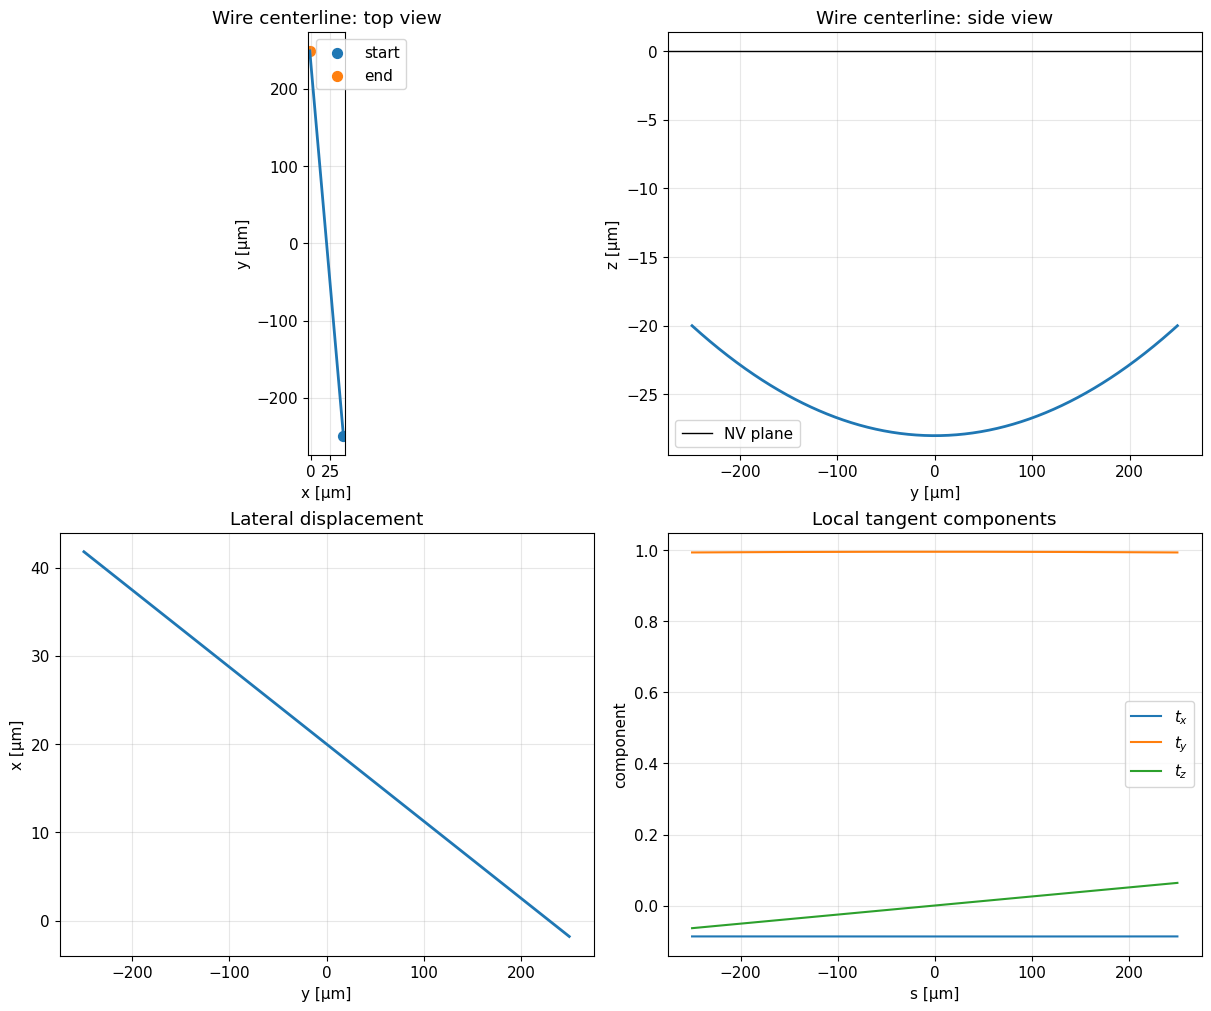

Wire geometry summary
---------------------
x range [µm]: -1.79 to 41.79
y range [µm]: -249.05 to 249.05
z range [µm]: -28.00 to -20.00

Local tangent summary
---------------------
max |tx| = 0.0872
max |ty| = 0.9962
max |tz| = 0.0638

Interpretation:
A mostly straight wire should have |ty| close to 1.
A moderate end bend can have max |tx| around 0.2--0.4.
Very large |tx| > 0.5 would mean the wire is becoming strongly kinked.


In [50]:
# ============================================================
# Plot and diagnose the actual wire geometry
# ============================================================

wire_xyz_um = make_small_wire_centerline_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_points=N_POLYLINE_SEGMENTS + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_end_pull=USE_END_PULL,
    end_pull_amplitude_um=WIRE_END_PULL_AMPLITUDE_UM,
    end_pull_center_um=WIRE_END_PULL_CENTER_UM,
    end_pull_width_um=WIRE_END_PULL_WIDTH_UM,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# Top view
axes[0, 0].plot(wire_xyz_um[:, 0], wire_xyz_um[:, 1], lw=2)
axes[0, 0].scatter(wire_xyz_um[0, 0], wire_xyz_um[0, 1], s=50, label="start")
axes[0, 0].scatter(wire_xyz_um[-1, 0], wire_xyz_um[-1, 1], s=50, label="end")
axes[0, 0].set_title("Wire centerline: top view")
axes[0, 0].set_xlabel("x [µm]")
axes[0, 0].set_ylabel("y [µm]")
axes[0, 0].set_aspect("equal")
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# Side view
axes[0, 1].plot(wire_xyz_um[:, 1], wire_xyz_um[:, 2], lw=2)
axes[0, 1].axhline(0, color="black", lw=1, label="NV plane")
axes[0, 1].set_title("Wire centerline: side view")
axes[0, 1].set_xlabel("y [µm]")
axes[0, 1].set_ylabel("z [µm]")
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# x displacement vs y
axes[1, 0].plot(wire_xyz_um[:, 1], wire_xyz_um[:, 0], lw=2)
axes[1, 0].set_title("Lateral displacement")
axes[1, 0].set_xlabel("y [µm]")
axes[1, 0].set_ylabel("x [µm]")
axes[1, 0].grid(True, alpha=0.3)

# Tangent components
dwire = np.diff(wire_xyz_um, axis=0)
ds = np.linalg.norm(dwire, axis=1)

tx = dwire[:, 0] / ds
ty = dwire[:, 1] / ds
tz = dwire[:, 2] / ds

s_mid = np.linspace(-WIRE_LENGTH_UM / 2, WIRE_LENGTH_UM / 2, N_POLYLINE_SEGMENTS)

axes[1, 1].plot(s_mid, tx, label=r"$t_x$")
axes[1, 1].plot(s_mid, ty, label=r"$t_y$")
axes[1, 1].plot(s_mid, tz, label=r"$t_z$")
axes[1, 1].set_title("Local tangent components")
axes[1, 1].set_xlabel("s [µm]")
axes[1, 1].set_ylabel("component")
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].legend()

plt.show()

print("Wire geometry summary")
print("---------------------")
print(f"x range [µm]: {wire_xyz_um[:,0].min():.2f} to {wire_xyz_um[:,0].max():.2f}")
print(f"y range [µm]: {wire_xyz_um[:,1].min():.2f} to {wire_xyz_um[:,1].max():.2f}")
print(f"z range [µm]: {wire_xyz_um[:,2].min():.2f} to {wire_xyz_um[:,2].max():.2f}")

print("\nLocal tangent summary")
print("---------------------")
print(f"max |tx| = {np.max(np.abs(tx)):.4f}")
print(f"max |ty| = {np.max(np.abs(ty)):.4f}")
print(f"max |tz| = {np.max(np.abs(tz)):.4f}")

print("\nInterpretation:")
print("A mostly straight wire should have |ty| close to 1.")
print("A moderate end bend can have max |tx| around 0.2--0.4.")
print("Very large |tx| > 0.5 would mean the wire is becoming strongly kinked.")

## wire models biot approx and cylindrical wire 2 functions


SI units internally:
   x,y,z in meters
   I in amperes
   B in tesla 
 Output:  B in nT


In [51]:
# ============================================================
# Approximation 1: thin-wire Biot-Savart line integral
# ============================================================

def simulate_wire_biot_savart_line(
    x_um,
    y_um,
    I_A,
    wire_xyz_um,
):
    """
    Magnetic field from a thin current-carrying wire.

    The wire is represented by a 3D polyline.
    Each segment contributes

        dB = mu0 I / (4 pi) * dl x R / |R|^3

    Parameters
    ----------
    x_um, y_um:
        Observation grid in micrometers.

    I_A:
        Current in amperes.

    wire_xyz_um:
        Wire centerline, shape (N, 3), in micrometers.

    Returns
    -------
    B_nT:
        Array with shape (3, Ny, Nx), ordered [Bx, By, Bz].
    """

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    wire_xyz_m = wire_xyz_um * 1e-6

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 * I_A / (4.0 * np.pi)

    for k in range(len(wire_xyz_m) - 1):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        dl = r2 - r1
        r_mid = 0.5 * (r1 + r2)

        Rx = X - r_mid[0]
        Ry = Y - r_mid[1]
        Rz = Z - r_mid[2]

        R2 = Rx**2 + Ry**2 + Rz**2
        R = np.sqrt(R2)
        R3 = np.where(R < 1e-15, 1e-45, R**3)

        cross_x = dl[1] * Rz - dl[2] * Ry
        cross_y = dl[2] * Rx - dl[0] * Rz
        cross_z = dl[0] * Ry - dl[1] * Rx

        Bx_T += prefactor * cross_x / R3
        By_T += prefactor * cross_y / R3
        Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)


# ============================================================
# Approximation 2: finite cylindrical wire volume integration
# ============================================================

def perpendicular_basis_from_tangent(t_hat):
    """
    Given a local tangent vector, construct two perpendicular unit vectors
    spanning the circular cross-section.
    """
    t_hat = np.asarray(t_hat, dtype=float)
    t_hat = t_hat / np.linalg.norm(t_hat)

    ref = np.array([0.0, 0.0, 1.0])

    if abs(np.dot(t_hat, ref)) > 0.95:
        ref = np.array([1.0, 0.0, 0.0])

    n1 = np.cross(t_hat, ref)
    n1 = n1 / np.linalg.norm(n1)

    n2 = np.cross(t_hat, n1)
    n2 = n2 / np.linalg.norm(n2)

    return n1, n2


def circular_cross_section_offsets_um(radius_um, n_cross):
    """
    Sample a circular cross-section using a square grid and keep points
    inside the radius.
    """
    a_values = np.linspace(-radius_um, radius_um, n_cross)
    b_values = np.linspace(-radius_um, radius_um, n_cross)

    offsets = []

    for a in a_values:
        for b in b_values:
            if a**2 + b**2 <= radius_um**2:
                offsets.append((a, b))

    offsets = np.asarray(offsets, dtype=float)

    if len(offsets) == 0:
        raise ValueError("No cross-section points selected. Increase n_cross.")

    return offsets


def simulate_wire_finite_cylinder_volume(
    x_um,
    y_um,
    I_A,
    wire_xyz_um,
    radius_um,
    n_cross=9,
):
    """
    Magnetic field from a finite-radius wire following a 3D centerline.

    The wire volume is approximated by:
      - line segments along the centerline,
      - circular cross-section samples perpendicular to each segment.

    Each volume element contributes

        dB = mu0/(4 pi) * J dV x R / |R|^3

    where J points along the local tangent of the wire.
    """

    X = x_um * 1e-6
    Y = y_um * 1e-6
    Z = np.zeros_like(X)

    wire_xyz_m = wire_xyz_um * 1e-6

    radius_m = radius_um * 1e-6
    area_m2 = np.pi * radius_m**2
    J_A_per_m2 = I_A / area_m2

    offsets_um = circular_cross_section_offsets_um(
        radius_um=radius_um,
        n_cross=n_cross,
    )

    dA_m2 = area_m2 / len(offsets_um)

    Bx_T = np.zeros_like(X, dtype=float)
    By_T = np.zeros_like(X, dtype=float)
    Bz_T = np.zeros_like(X, dtype=float)

    prefactor = mu0 / (4.0 * np.pi)

    for k in range(len(wire_xyz_m) - 1):
        r1 = wire_xyz_m[k]
        r2 = wire_xyz_m[k + 1]

        dl_vec = r2 - r1
        ds_m = np.linalg.norm(dl_vec)

        if ds_m == 0:
            continue

        t_hat = dl_vec / ds_m
        n1, n2 = perpendicular_basis_from_tangent(t_hat)

        r_mid = 0.5 * (r1 + r2)

        # Vector current-volume element
        JdV_vec = J_A_per_m2 * dA_m2 * ds_m * t_hat

        for a_um, b_um in offsets_um:
            offset_m = (a_um * 1e-6) * n1 + (b_um * 1e-6) * n2
            source = r_mid + offset_m

            Rx = X - source[0]
            Ry = Y - source[1]
            Rz = Z - source[2]

            R2 = Rx**2 + Ry**2 + Rz**2
            R = np.sqrt(R2)
            R3 = np.where(R < 1e-15, 1e-45, R**3)

            cross_x = JdV_vec[1] * Rz - JdV_vec[2] * Ry
            cross_y = JdV_vec[2] * Rx - JdV_vec[0] * Rz
            cross_z = JdV_vec[0] * Ry - JdV_vec[1] * Rx

            Bx_T += prefactor * cross_x / R3
            By_T += prefactor * cross_y / R3
            Bz_T += prefactor * cross_z / R3

    return 1e9 * np.stack([Bx_T, By_T, Bz_T], axis=0)

In [52]:
# ============================================================
# Simulate POS and NEG fields with both approximations
# ============================================================

wire_xyz_um = make_small_wire_centerline_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_points=N_POLYLINE_SEGMENTS + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_end_pull=USE_END_PULL,
    end_pull_amplitude_um=WIRE_END_PULL_AMPLITUDE_UM,
    end_pull_center_um=WIRE_END_PULL_CENTER_UM,
    end_pull_width_um=WIRE_END_PULL_WIDTH_UM,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

# Thin-wire Biot-Savart line model
B_pos_sim_line = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_POS_A,
    wire_xyz_um=wire_xyz_um,
)

B_neg_sim_line = simulate_wire_biot_savart_line(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_NEG_A,
    wire_xyz_um=wire_xyz_um,
)

# Finite cylindrical volume model
# Use a lower number of centerline points for cylinder if needed for speed.
wire_xyz_cylinder_um = make_small_wire_centerline_um(
    length_um=WIRE_LENGTH_UM,
    x0_um=WIRE_X0_UM,
    y0_um=WIRE_Y0_UM,
    height_um=EFFECTIVE_HEIGHT_UM,
    theta_deg=WIRE_THETA_DEG,
    center_raise_um=WIRE_CENTER_RAISE_UM,
    side_bow_um=WIRE_SIDE_BOW_UM,
    n_points=N_CYLINDER_LENGTH + 1,
    sensor_z_sign=SENSOR_Z_SIGN,
    use_end_pull=USE_END_PULL,
    end_pull_amplitude_um=WIRE_END_PULL_AMPLITUDE_UM,
    end_pull_center_um=WIRE_END_PULL_CENTER_UM,
    end_pull_width_um=WIRE_END_PULL_WIDTH_UM,
    use_local_kink=USE_LOCAL_KINK,
    kink_amplitude_um=WIRE_KINK_AMPLITUDE_UM,
    kink_center_um=WIRE_KINK_CENTER_UM,
    kink_width_um=WIRE_KINK_WIDTH_UM,
)

B_pos_sim_cylinder = simulate_wire_finite_cylinder_volume(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_POS_A,
    wire_xyz_um=wire_xyz_cylinder_um,
    radius_um=WIRE_RADIUS_UM,
    n_cross=N_CYLINDER_CROSS,
)

B_neg_sim_cylinder = simulate_wire_finite_cylinder_volume(
    x_um=x_grid_um,
    y_um=y_grid_um,
    I_A=I_NEG_A,
    wire_xyz_um=wire_xyz_cylinder_um,
    radius_um=WIRE_RADIUS_UM,
    n_cross=N_CYLINDER_CROSS,
)

print("Finished simulations.")
print("---------------------")
print("Available simulated fields:")
print("B_pos_sim_line, B_neg_sim_line")
print("B_pos_sim_cylinder, B_neg_sim_cylinder")

Finished simulations.
---------------------
Available simulated fields:
B_pos_sim_line, B_neg_sim_line
B_pos_sim_cylinder, B_neg_sim_cylinder


In [53]:
# ============================================================
# Choose model to plot
# ============================================================

MODEL_TO_PLOT = "line"
# Options:
#   "line"
#   "finite_cylinder"

if MODEL_TO_PLOT == "line":
    B_pos_sim = B_pos_sim_line
    B_neg_sim = B_neg_sim_line
elif MODEL_TO_PLOT == "finite_cylinder":
    B_pos_sim = B_pos_sim_cylinder
    B_neg_sim = B_neg_sim_cylinder
else:
    raise ValueError("MODEL_TO_PLOT must be 'line' or 'finite_cylinder'.")

print(f"Plotting model: {MODEL_TO_PLOT}")

Plotting model: line


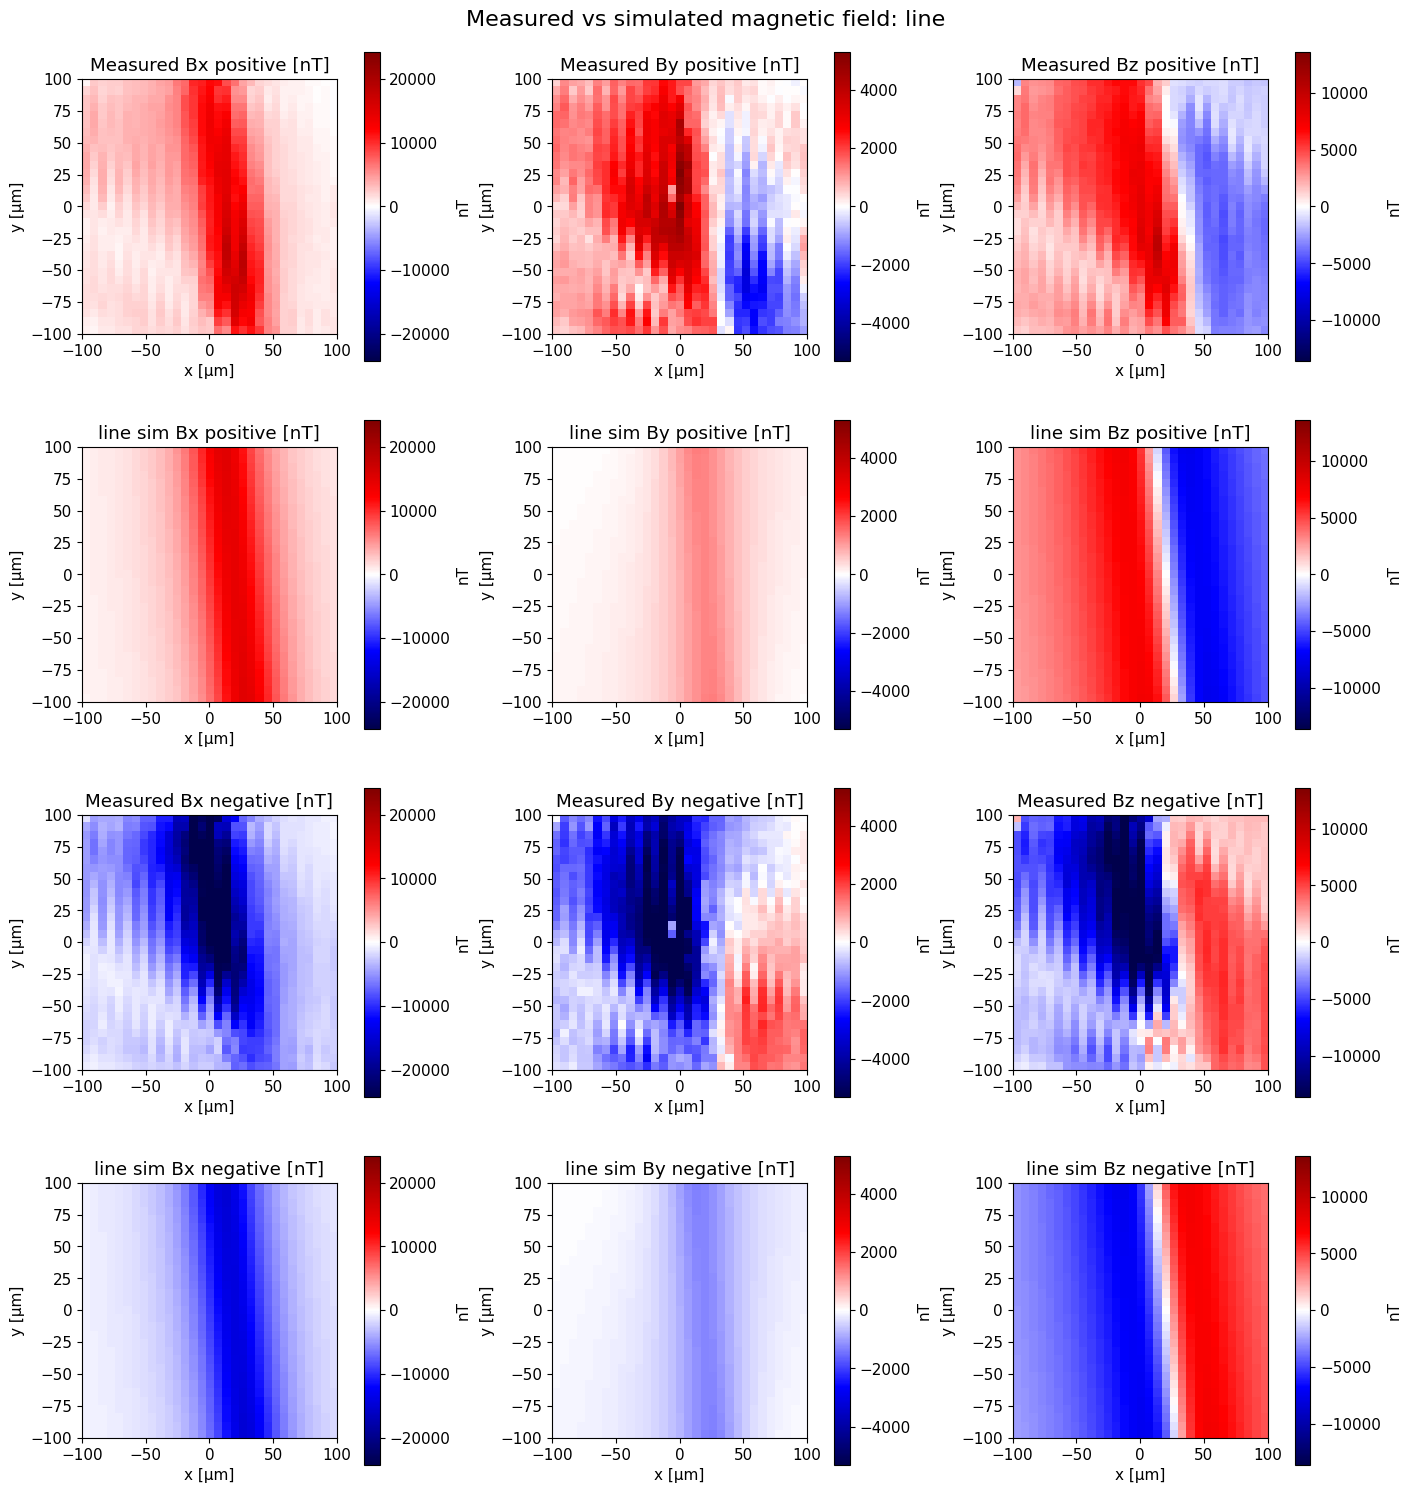

In [54]:
# ============================================================
# Direct comparison: measured POS/NEG vs simulated POS/NEG
# ============================================================

fig, axes = plt.subplots(4, 3, figsize=(14, 15), constrained_layout=True)

for i, comp in enumerate(B_COMPONENTS):
    measured_pos = B_pos_meas[i]
    measured_neg = B_neg_meas[i]
    simulated_pos = B_pos_sim[i]
    simulated_neg = B_neg_sim[i]

    lim = max(
        np.nanpercentile(np.abs(measured_pos), 95),
        np.nanpercentile(np.abs(measured_neg), 95),
        np.nanpercentile(np.abs(simulated_pos), 95),
        np.nanpercentile(np.abs(simulated_neg), 95),
    )

    if lim == 0 or not np.isfinite(lim):
        lim = 1.0

    maps = [
        (measured_pos, f"Measured {comp} positive [nT]"),
        (simulated_pos, f"{MODEL_TO_PLOT} sim {comp} positive [nT]"),
        (measured_neg, f"Measured {comp} negative [nT]"),
        (simulated_neg, f"{MODEL_TO_PLOT} sim {comp} negative [nT]"),
    ]

    for row_i, (data, title) in enumerate(maps):
        im = axes[row_i, i].imshow(
            data,
            extent=extent_um,
            origin="lower",
            aspect="equal",
            cmap=CMAP,
            vmin=-lim,
            vmax=lim,
        )

        axes[row_i, i].set_title(title)
        axes[row_i, i].set_xlabel("x [µm]")
        axes[row_i, i].set_ylabel("y [µm]")
        plt.colorbar(im, ax=axes[row_i, i], label="nT")

fig.suptitle(f"Measured vs simulated magnetic field: {MODEL_TO_PLOT}", fontsize=16)
plt.show()

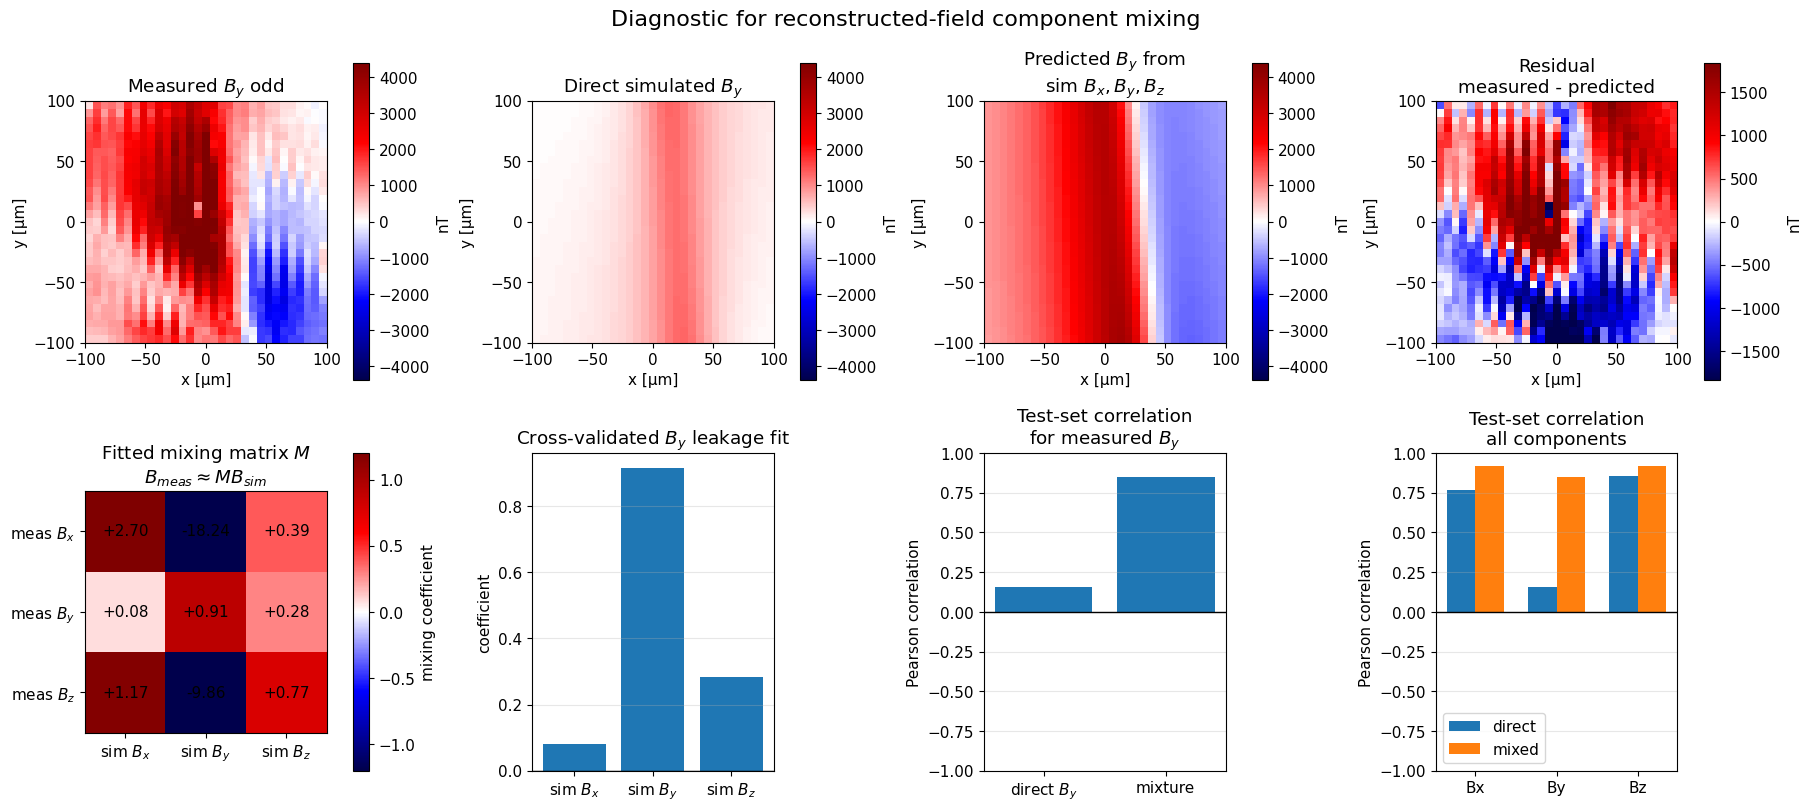


Direct component agreement:


,component,direct_corr_all_pixels,direct_rms_nT_all_pixels
0,Bx,0.803344,3387.397255
1,By,0.174639,1893.902894
2,Bz,0.850342,3109.105449



By-specific leakage test, trained on 70% pixels and tested on 30%:


,test,train_corr,test_corr,train_rms_nT,test_rms_nT
0,By direct simulation,0.182365,0.155869,1855.263866,1980.83693
1,By predicted by Bx/By/Bz mixture,0.829990,0.847537,996.061426,990.00281



Full 3x3 mixing matrix M, trained on 70% pixels:


,sim_Bx,sim_By,sim_Bz
measured_Bx,2.704882,-18.243432,0.392420
measured_By,0.080479,0.914214,0.283942
measured_Bz,1.173314,-9.855431,0.773535



Full vector direct vs mixed test-set comparison:


,component,direct_corr_test,mixed_corr_test,direct_rms_test_nT,mixed_rms_test_nT
0,Bx,0.769274,0.920745,3606.326368,2110.480967
1,By,0.155869,0.847537,1980.836930,990.002810
2,Bz,0.852876,0.916095,3179.612273,1882.073196



Report interpretation:
----------------------
If the mixture test-set correlation for By is much larger than the direct By correlation, then the measured By map is not well explained by the physical simulated By component alone.
In that case, measured By is consistent with component mixing: reconstructed By contains contributions with the spatial structure of simulated Bx and/or Bz.
This does not prove the A-matrix is wrong, but it is evidence that the vector reconstruction, lab-frame convention, NV-axis assignment, or calibration matrix may mix field components.
Because the lead-geometry scan only weakly improved By while the component-mixture model strongly improved it, the dominant issue is more likely vector-component mixing than missing wire bending.


In [55]:
# ============================================================
# REPORT DIAGNOSTIC:
# Is reconstructed By a physical wire-geometry effect,
# or is it consistent with component mixing / leakage?
# ============================================================
#
# Required existing variables:
#   B_odd_meas       shape (3, Ny, Nx), measured odd field [nT]
#   B_pos_sim_line   shape (3, Ny, Nx), +current Biot-Savart simulation [nT]
#   B_COMPONENTS     ["Bx", "By", "Bz"]
#   extent_um
#   grid_size
#   CMAP
#
# Logic:
#   1. Compare measured By directly with simulated By.
#   2. Fit measured By as a linear mixture of simulated Bx, By, Bz.
#   3. Use train/test split so this is not just overfitting.
#   4. Fit a full 3x3 mixing matrix B_meas ≈ M @ B_sim.
#   5. Plot report-ready maps and print interpretation.
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

# -----------------------------
# Inputs
# -----------------------------
B_meas = B_odd_meas          # measured current-reversing field
B_sim = B_pos_sim_line       # simulated +2 mA field, comparable to B_odd

component_names = B_COMPONENTS

# Flatten: rows = pixels, columns = Bx, By, Bz
X = np.column_stack([
    B_sim[0].ravel(),
    B_sim[1].ravel(),
    B_sim[2].ravel(),
])

Y = np.column_stack([
    B_meas[0].ravel(),
    B_meas[1].ravel(),
    B_meas[2].ravel(),
])

valid = np.all(np.isfinite(X), axis=1) & np.all(np.isfinite(Y), axis=1)

Xv = X[valid]
Yv = Y[valid]

# -----------------------------
# Train/test split
# -----------------------------
rng = np.random.default_rng(7)
idx = np.arange(Xv.shape[0])
rng.shuffle(idx)

n_train = int(0.70 * len(idx))
train_idx = idx[:n_train]
test_idx = idx[n_train:]

X_train = Xv[train_idx]
Y_train = Yv[train_idx]

X_test = Xv[test_idx]
Y_test = Yv[test_idx]


def corr(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    if np.sum(m) < 5 or np.std(a[m]) == 0 or np.std(b[m]) == 0:
        return np.nan
    return np.corrcoef(a[m], b[m])[0, 1]


def rms(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    m = np.isfinite(a) & np.isfinite(b)
    return np.sqrt(np.nanmean((a[m] - b[m])**2))


# ============================================================
# 1. Direct component agreement
# ============================================================

direct_rows = []

for i, comp in enumerate(component_names):
    direct_rows.append({
        "component": comp,
        "direct_corr_all_pixels": corr(Yv[:, i], Xv[:, i]),
        "direct_rms_nT_all_pixels": rms(Yv[:, i], Xv[:, i]),
    })

direct_df = pd.DataFrame(direct_rows)

# ============================================================
# 2. Specific By leakage test:
#    By_meas ≈ a Bx_sim + b By_sim + c Bz_sim
# ============================================================

target_train = Y_train[:, 1]  # measured By
target_test = Y_test[:, 1]

coef_By, *_ = lstsq(X_train, target_train, rcond=None)

By_pred_all_flat = X @ coef_By
By_pred_all = np.full(B_meas[1].size, np.nan)
By_pred_all[valid] = By_pred_all_flat
By_pred_all = By_pred_all.reshape(B_meas[1].shape)

By_pred_train = X_train @ coef_By
By_pred_test = X_test @ coef_By

By_direct_train = X_train[:, 1]
By_direct_test = X_test[:, 1]

by_summary = pd.DataFrame([{
    "test": "By direct simulation",
    "train_corr": corr(target_train, By_direct_train),
    "test_corr": corr(target_test, By_direct_test),
    "train_rms_nT": rms(target_train, By_direct_train),
    "test_rms_nT": rms(target_test, By_direct_test),
}, {
    "test": "By predicted by Bx/By/Bz mixture",
    "train_corr": corr(target_train, By_pred_train),
    "test_corr": corr(target_test, By_pred_test),
    "train_rms_nT": rms(target_train, By_pred_train),
    "test_rms_nT": rms(target_test, By_pred_test),
}])

# ============================================================
# 3. Full vector mixing matrix:
#    B_meas ≈ M @ B_sim
# ============================================================

# Solve X_train @ M.T ≈ Y_train
M_T, *_ = lstsq(X_train, Y_train, rcond=None)
M = M_T.T

Y_pred_all_flat = X @ M.T

B_pred_mixed = np.full_like(Y, np.nan, dtype=float)
B_pred_mixed[valid] = Y_pred_all_flat

B_pred_mixed = np.stack([
    B_pred_mixed[:, 0].reshape(grid_size, grid_size),
    B_pred_mixed[:, 1].reshape(grid_size, grid_size),
    B_pred_mixed[:, 2].reshape(grid_size, grid_size),
], axis=0)

Y_pred_test = X_test @ M.T

full_mix_rows = []

for i, comp in enumerate(component_names):
    full_mix_rows.append({
        "component": comp,
        "direct_corr_test": corr(Y_test[:, i], X_test[:, i]),
        "mixed_corr_test": corr(Y_test[:, i], Y_pred_test[:, i]),
        "direct_rms_test_nT": rms(Y_test[:, i], X_test[:, i]),
        "mixed_rms_test_nT": rms(Y_test[:, i], Y_pred_test[:, i]),
    })

full_mix_df = pd.DataFrame(full_mix_rows)

M_df = pd.DataFrame(
    M,
    index=["measured_Bx", "measured_By", "measured_Bz"],
    columns=["sim_Bx", "sim_By", "sim_Bz"],
)

# ============================================================
# 4. Report plots
# ============================================================

fig, axes = plt.subplots(2, 4, figsize=(18, 8), constrained_layout=True)

# By-specific maps
By_measured = B_meas[1]
By_direct = B_sim[1]
By_mixed = By_pred_all
By_residual = By_measured - By_mixed

lim_by = max(
    np.nanpercentile(np.abs(By_measured), 95),
    np.nanpercentile(np.abs(By_direct), 95),
    np.nanpercentile(np.abs(By_mixed), 95),
)

lim_res = np.nanpercentile(np.abs(By_residual), 95)

if lim_by == 0 or not np.isfinite(lim_by):
    lim_by = 1.0
if lim_res == 0 or not np.isfinite(lim_res):
    lim_res = 1.0

maps_top = [
    (By_measured, "Measured $B_y$ odd", lim_by),
    (By_direct, "Direct simulated $B_y$", lim_by),
    (By_mixed, "Predicted $B_y$ from\nsim $B_x,B_y,B_z$", lim_by),
    (By_residual, "Residual\nmeasured - predicted", lim_res),
]

for ax, (data, title, lim) in zip(axes[0], maps_top):
    im = ax.imshow(
        data,
        extent=extent_um,
        origin="lower",
        aspect="equal",
        cmap=CMAP,
        vmin=-lim,
        vmax=lim,
    )
    ax.set_title(title)
    ax.set_xlabel("x [µm]")
    ax.set_ylabel("y [µm]")
    plt.colorbar(im, ax=ax, label="nT")

# Full mixing matrix heatmap
imM = axes[1, 0].imshow(M, cmap="seismic", vmin=-1.2, vmax=1.2)
axes[1, 0].set_title("Fitted mixing matrix $M$\n$B_{meas} \\approx M B_{sim}$")
axes[1, 0].set_xticks(range(3))
axes[1, 0].set_yticks(range(3))
axes[1, 0].set_xticklabels(["sim $B_x$", "sim $B_y$", "sim $B_z$"])
axes[1, 0].set_yticklabels(["meas $B_x$", "meas $B_y$", "meas $B_z$"])
for i in range(3):
    for j in range(3):
        axes[1, 0].text(j, i, f"{M[i,j]:+.2f}", ha="center", va="center", color="black")
plt.colorbar(imM, ax=axes[1, 0], label="mixing coefficient")

# Bar plot: By coefficients
axes[1, 1].bar(["sim $B_x$", "sim $B_y$", "sim $B_z$"], coef_By)
axes[1, 1].axhline(0, color="black", lw=1)
axes[1, 1].set_title("Cross-validated $B_y$ leakage fit")
axes[1, 1].set_ylabel("coefficient")
axes[1, 1].grid(True, axis="y", alpha=0.3)

# Correlation comparison for By
axes[1, 2].bar(
    ["direct $B_y$", "mixture"],
    [by_summary.loc[0, "test_corr"], by_summary.loc[1, "test_corr"]],
)
axes[1, 2].set_ylim(-1, 1)
axes[1, 2].axhline(0, color="black", lw=1)
axes[1, 2].set_title("Test-set correlation\nfor measured $B_y$")
axes[1, 2].set_ylabel("Pearson correlation")
axes[1, 2].grid(True, axis="y", alpha=0.3)

# Component test correlations: direct vs mixed
x = np.arange(3)
width = 0.35
axes[1, 3].bar(
    x - width/2,
    full_mix_df["direct_corr_test"],
    width,
    label="direct",
)
axes[1, 3].bar(
    x + width/2,
    full_mix_df["mixed_corr_test"],
    width,
    label="mixed",
)
axes[1, 3].set_xticks(x)
axes[1, 3].set_xticklabels(component_names)
axes[1, 3].set_ylim(-1, 1)
axes[1, 3].axhline(0, color="black", lw=1)
axes[1, 3].set_title("Test-set correlation\nall components")
axes[1, 3].set_ylabel("Pearson correlation")
axes[1, 3].legend()
axes[1, 3].grid(True, axis="y", alpha=0.3)

plt.suptitle("Diagnostic for reconstructed-field component mixing", fontsize=16)
plt.show()

# ============================================================
# 5. Print report-ready tables and interpretation
# ============================================================

print("\nDirect component agreement:")
display(direct_df)

print("\nBy-specific leakage test, trained on 70% pixels and tested on 30%:")
display(by_summary)

print("\nFull 3x3 mixing matrix M, trained on 70% pixels:")
display(M_df)

print("\nFull vector direct vs mixed test-set comparison:")
display(full_mix_df)

print("\nReport interpretation:")
print("----------------------")
print(
    "If the mixture test-set correlation for By is much larger than the direct "
    "By correlation, then the measured By map is not well explained by the "
    "physical simulated By component alone."
)
print(
    "In that case, measured By is consistent with component mixing: reconstructed "
    "By contains contributions with the spatial structure of simulated Bx and/or Bz."
)
print(
    "This does not prove the A-matrix is wrong, but it is evidence that the vector "
    "reconstruction, lab-frame convention, NV-axis assignment, or calibration matrix "
    "may mix field components."
)
print(
    "Because the lead-geometry scan only weakly improved By while the component-mixture "
    "model strongly improved it, the dominant issue is more likely vector-component "
    "mixing than missing wire bending."
)